# Notebook 01 - Visualização Geral dos Dados
Este notebook faz uma análise exploratória inicial do MIMIC-III 10k.
Inclui visualizações sobre pacientes, admissões, internações na UTI e mortalidade.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configurações gerais
sns.set(style='whitegrid')
%matplotlib inline

# Define caminho base dos dados
DATA_DIR = Path('../data/Mimic-3_patients/')
FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def load_csv_data(file_path):
    """Carrega arquivo CSV dado o caminho completo."""
    df = pd.read_csv(file_path)
    print(f"{file_path.name} -> shape: {df.shape}")
    return df


In [3]:
admissions = load_csv_data(DATA_DIR / 'ADMISSIONS' / 'ADMISSIONS_sorted.csv')
patients = load_csv_data(DATA_DIR / 'PATIENTS' / 'PATIENTS_sorted.csv')
icustays = load_csv_data(DATA_DIR / 'ICUSTAYS' / 'ICUSTAYS_sorted.csv')


ADMISSIONS_sorted.csv -> shape: (12911, 19)
PATIENTS_sorted.csv -> shape: (10000, 8)
ICUSTAYS_sorted.csv -> shape: (13436, 12)


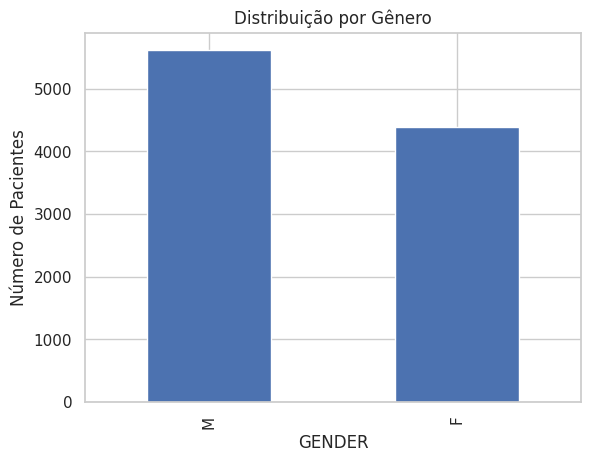

In [4]:
def plot_gender_distribution(df):
    """Plota distribuição de sexo dos pacientes."""
    gender_counts = df['GENDER'].value_counts()
    gender_counts.plot(kind='bar', title='Distribuição por Gênero')
    plt.ylabel("Número de Pacientes")
    plt.savefig(FIGURES_DIR / 'gender_distribution.png')
    plt.show()

plot_gender_distribution(patients)


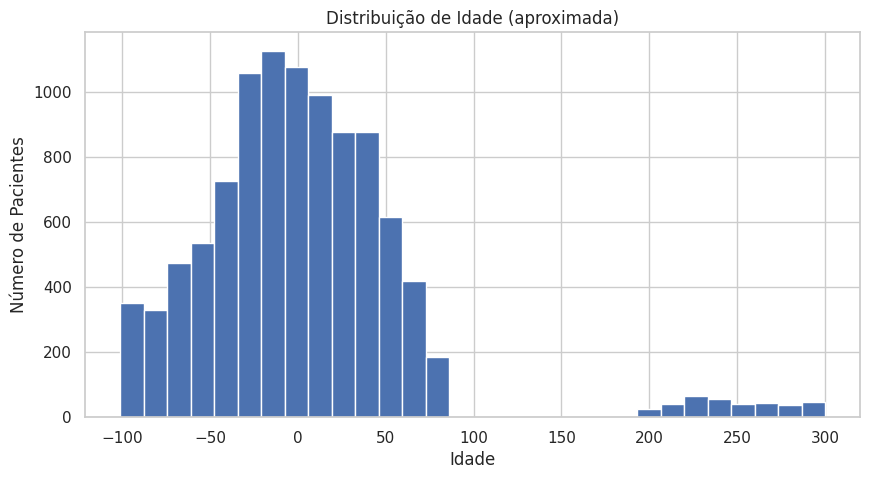

In [5]:
def plot_age_distribution(df):
    """Plota histograma da idade dos pacientes."""
    plt.figure(figsize=(10,5))
    df['AGE'] = df['DOB'].apply(lambda x: 2100 - int(x[:4]))  # aproximação artificial
    df['AGE'].hist(bins=30)
    plt.title('Distribuição de Idade (aproximada)')
    plt.xlabel('Idade')
    plt.ylabel('Número de Pacientes')
    plt.savefig(FIGURES_DIR / 'age_distribution.png')
    plt.show()

plot_age_distribution(patients)


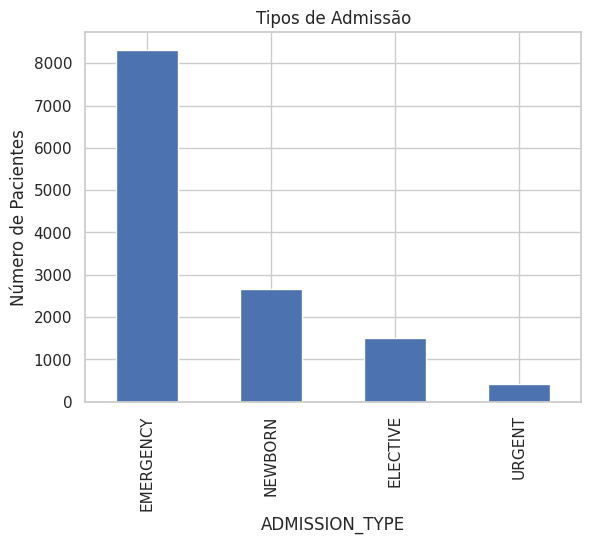

In [6]:
def plot_admission_types(df):
    """Mostra a distribuição dos tipos de admissão."""
    df['ADMISSION_TYPE'].value_counts().plot(kind='bar')
    plt.title('Tipos de Admissão')
    plt.ylabel('Número de Pacientes')
    plt.savefig(FIGURES_DIR / 'admission_types.png')
    plt.show()

plot_admission_types(admissions)


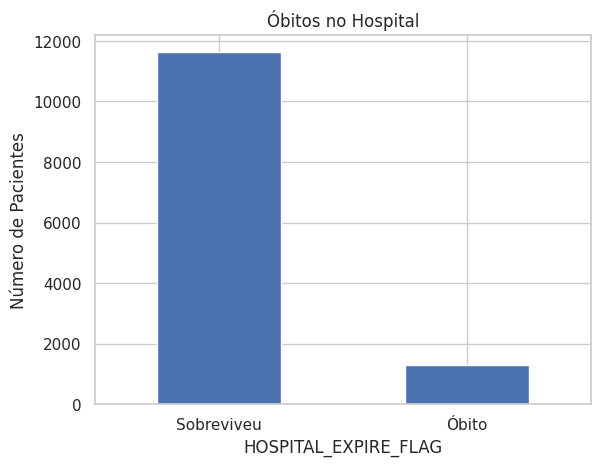

In [7]:
def plot_mortality(df):
    """Distribuição de mortalidade hospitalar e na UTI."""
    df['HOSPITAL_EXPIRE_FLAG'].value_counts().plot(kind='bar')
    plt.title('Óbitos no Hospital')
    plt.xticks([0,1], ['Sobreviveu', 'Óbito'], rotation=0)
    plt.ylabel('Número de Pacientes')
    plt.savefig(FIGURES_DIR / 'hospital_mortality.png')
    plt.show()

plot_mortality(admissions)


### ✅ Conclusões
- A base contém milhares de pacientes com variabilidade em idade e tipo de admissão.
- A mortalidade hospitalar é um desfecho importante que será usado em notebooks futuros.
- Próximo passo: extração de notas clínicas para análises com NLP.